In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for plots
sns.set_theme(style="whitegrid")

# Define paths
base_dir = Path.cwd().parent
processed_dir = base_dir / 'data' / 'processed'
visuals_dir = base_dir / 'visuals'
visuals_dir.mkdir(parents=True, exist_ok=True)

print("Loading Master Text Dataset...")
df = pd.read_csv(processed_dir / 'master_text_data.csv')

# --- DATA QUALITY REPORT ---
print("\n--- Data Quality Report ---")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\nMissing Values:")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_count}")

# Check data types
print("\nData Overview (Info):")
df.info()

Loading Master Text Dataset...

--- Data Quality Report ---
Total Rows: 81729
Total Columns: 2

Missing Values:
text     0
label    0
dtype: int64

Duplicate Rows: 0

Data Overview (Info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81729 entries, 0 to 81728
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    81729 non-null  object
 1   label   81729 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


Analyzing Target Variable (Class Distribution)...


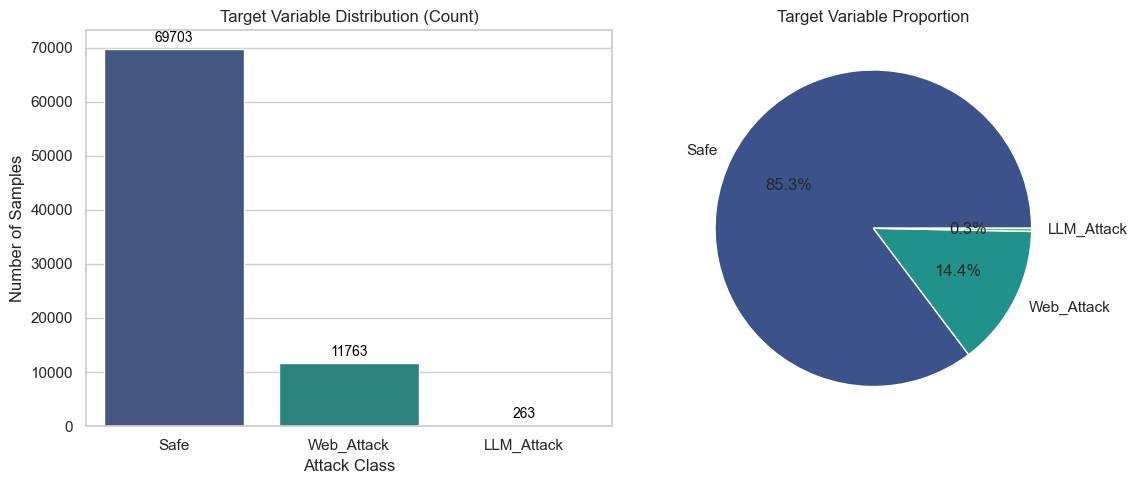

In [2]:
print("Analyzing Target Variable (Class Distribution)...")

plt.figure(figsize=(12, 5))

# Plot 1: Count Plot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df, x='label', palette='viridis')
plt.title('Target Variable Distribution (Count)')
plt.xlabel('Attack Class')
plt.ylabel('Number of Samples')
# Add count labels on top
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')

# Plot 2: Pie Chart
plt.subplot(1, 2, 2)
class_counts = df['label'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(class_counts)))
plt.title('Target Variable Proportion')

plt.tight_layout()
plt.savefig(visuals_dir / 'text_01_target_distribution.png', dpi=300)
plt.show()

Engineering meta-features and detecting outliers...

Meta-Features Description:
         char_count    word_count
count  81729.000000  81729.000000
mean     161.133698     24.804415
std      115.194066     18.709222
min        1.000000      1.000000
25%       32.000000      4.000000
50%      189.000000     30.000000
75%      244.000000     39.000000
max     4545.000000    783.000000


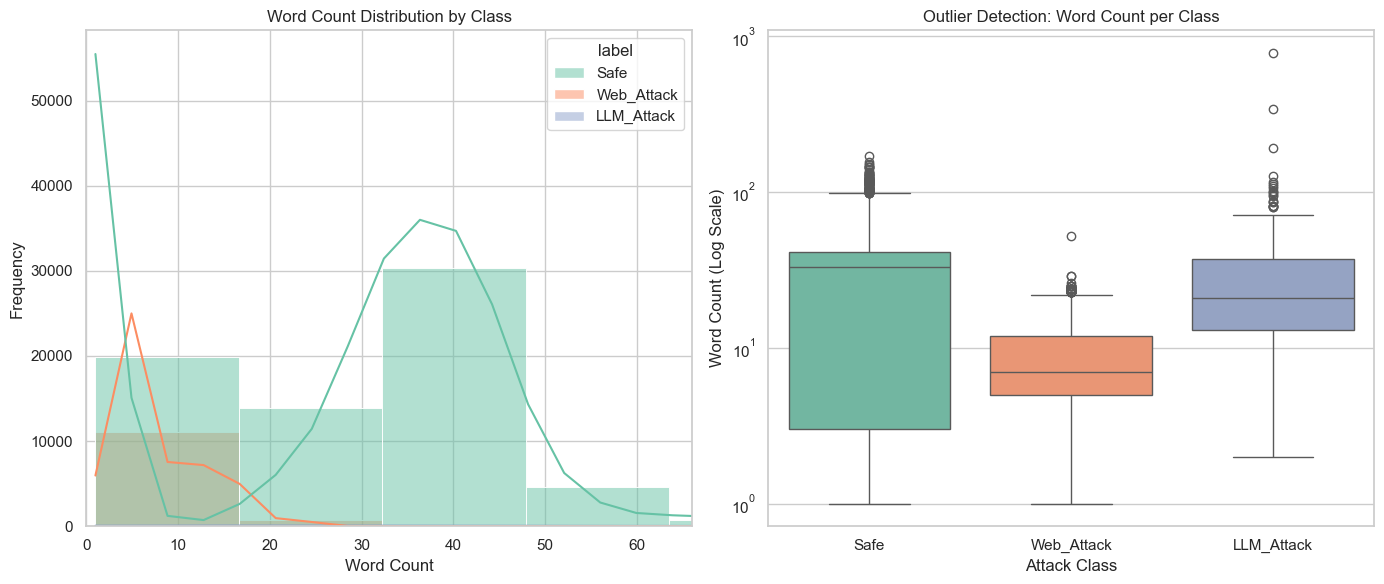

In [3]:
print("Engineering meta-features and detecting outliers...")

# Create meta-features for text
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Basic descriptive statistics
print("\nMeta-Features Description:")
print(df[['char_count', 'word_count']].describe())

plt.figure(figsize=(14, 6))

# Histogram for distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='word_count', hue='label', bins=50, kde=True, palette='Set2')
plt.title('Word Count Distribution by Class')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.xlim(0, df['word_count'].quantile(0.99)) # Cut off extreme tails for better view

# Boxplot for Outlier Detection
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='label', y='word_count', palette='Set2')
plt.title('Outlier Detection: Word Count per Class')
plt.xlabel('Attack Class')
plt.ylabel('Word Count (Log Scale)')
plt.yscale('log') # Use log scale because text lengths vary hugely

plt.tight_layout()
plt.savefig(visuals_dir / 'text_02_feature_outliers.png', dpi=300)
plt.show()

Generating N-Gram Analysis (Top Words)...


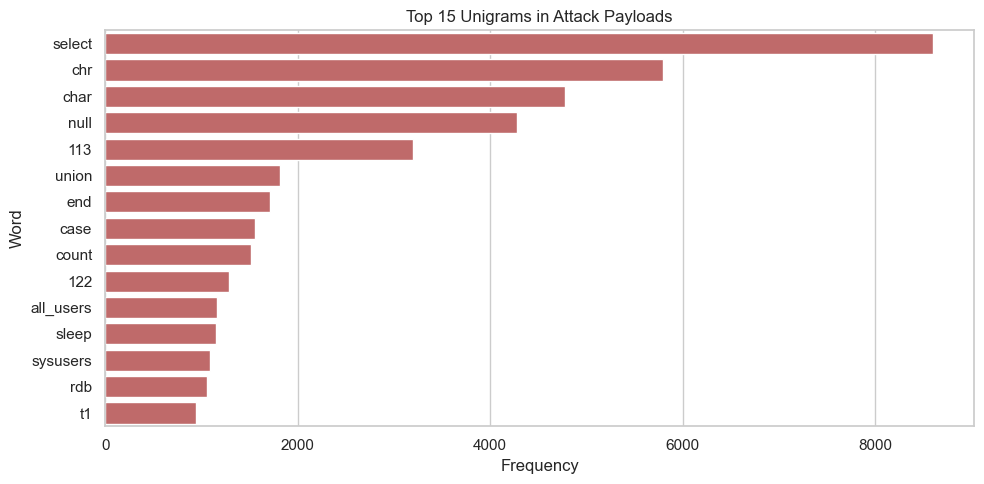

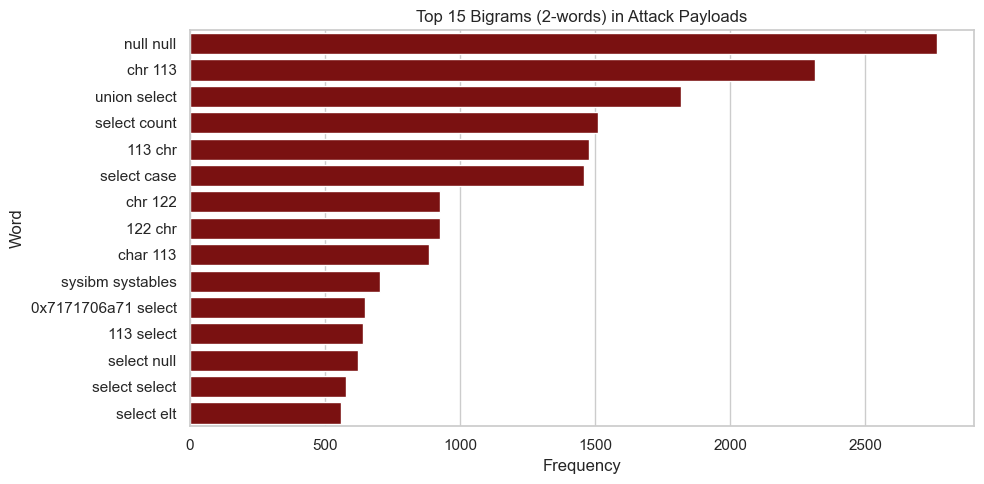

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

print("Generating N-Gram Analysis (Top Words)...")

def plot_top_ngrams(text_data, title, n_gram_range=(1, 1), color='blue'):
    # Limit to 10000 samples to prevent memory issues during EDA
    sample_texts = text_data.sample(min(10000, len(text_data)), random_state=42)
    
    vectorizer = CountVectorizer(stop_words='english', ngram_range=n_gram_range, max_features=20)
    X = vectorizer.fit_transform(sample_texts)
    
    words = vectorizer.get_feature_names_out()
    frequencies = X.sum(axis=0).A1
    
    freq_df = pd.DataFrame({'Word': words, 'Frequency': frequencies})
    freq_df = freq_df.sort_values(by='Frequency', ascending=False).head(15)
    
    plt.figure(figsize=(10, 5))
    sns.barplot(data=freq_df, x='Frequency', y='Word', color=color)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Extract top unigrams for attacks
attack_texts = df[df['label'].isin(['Web_Attack', 'LLM_Attack'])]['text'].astype(str)
plot_top_ngrams(attack_texts, 'Top 15 Unigrams in Attack Payloads', (1, 1), color='indianred')

# Extract top bigrams for attacks
plot_top_ngrams(attack_texts, 'Top 15 Bigrams (2-words) in Attack Payloads', (2, 2), color='darkred')

Performing Advanced Analysis: Correlation & PCA on Vectorized Text...


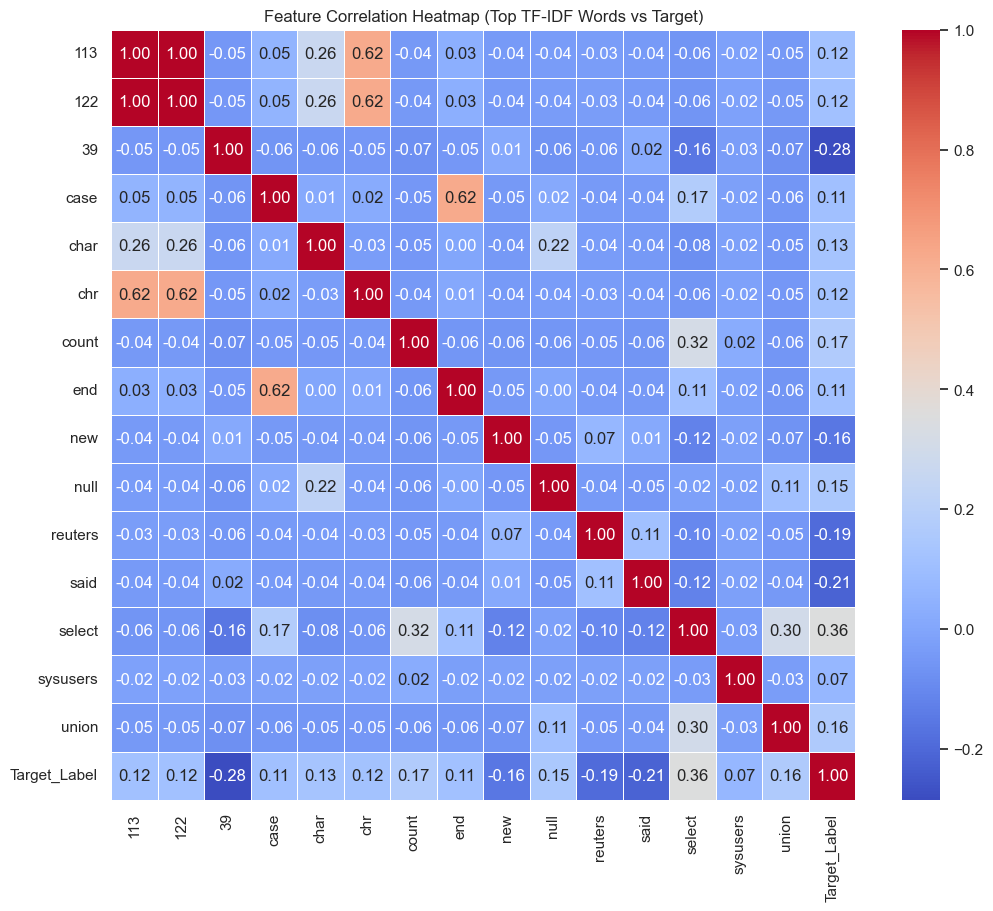


Top Correlations with Target_Label:
Target_Label    1.000000
select          0.357496
count           0.170685
union           0.163072
null            0.147899
Name: Target_Label, dtype: float64

Running PCA to visualize high-dimensional text data in 2D...


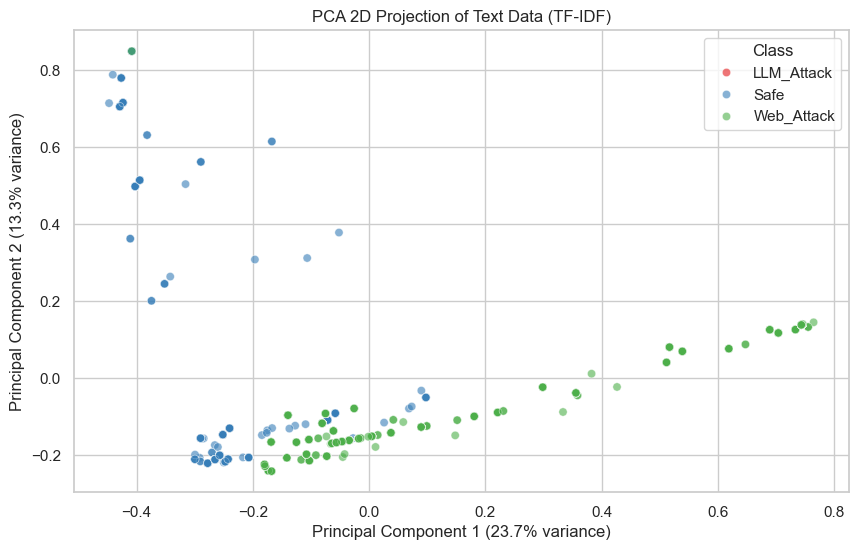

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

print("Performing Advanced Analysis: Correlation & PCA on Vectorized Text...")

# Take a stratified sample for advanced visual analytics to save memory
sample_df = df.groupby('label').apply(lambda x: x.sample(min(len(x), 2000), random_state=42)).reset_index(drop=True)

# Convert text to numbers using TF-IDF (Extracting top 15 most important features)
tfidf = TfidfVectorizer(max_features=15, stop_words='english')
X_tfidf = tfidf.fit_transform(sample_df['text'].astype(str)).toarray()
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame from the vectors
df_tfidf = pd.DataFrame(X_tfidf, columns=feature_names)
# Convert string labels to numbers for correlation
label_map = {'Safe': 0, 'Web_Attack': 1, 'LLM_Attack': 2}
df_tfidf['Target_Label'] = sample_df['label'].map(label_map)

# 1. Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df_tfidf.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap (Top TF-IDF Words vs Target)')
plt.savefig(visuals_dir / 'text_03_correlation_heatmap.png', dpi=300)
plt.show()

print("\nTop Correlations with Target_Label:")
print(corr_matrix['Target_Label'].sort_values(ascending=False).head(5))

# 2. PCA (Principal Component Analysis)
print("\nRunning PCA to visualize high-dimensional text data in 2D...")
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_tfidf)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=sample_df['label'], palette='Set1', alpha=0.6)
plt.title('PCA 2D Projection of Text Data (TF-IDF)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Class')
plt.savefig(visuals_dir / 'text_04_pca_projection.png', dpi=300)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

print("Preparing Data for Model Training (Train/Test Split)...")

# We use the full dataset for the actual split
X = df['text'].values
y = df['label'].values

# Stratify ensures the class ratios remain the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n--- Data Split Report ---")
print(f"Total Dataset Size: {len(X)}")
print(f"Training Set Size: {len(X_train)} (80%)")
print(f"Testing Set Size: {len(X_test)} (20%)")

# Verify stratification
print("\nTraining Set Class Distribution:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

print("\nEDA and Data Preparation Complete. Ready for Model Training!")

Preparing Data for Model Training (Train/Test Split)...

--- Data Split Report ---
Total Dataset Size: 81729
Training Set Size: 65383 (80%)
Testing Set Size: 16346 (20%)

Training Set Class Distribution:
Safe          85.285166
Web_Attack    14.392120
LLM_Attack     0.322714
Name: proportion, dtype: float64

EDA and Data Preparation Complete. Ready for Model Training!
